Ecuación cuadrática: 1x² + (-3x) + (2) = 0
Raíces exactas: x1 = 1, x2 = 2

Resultados del Algoritmo Genético:
  GA -> x1 = 1.9956, x2 = 1.0105, errores = 4.39e-03, 1.04e-02

Resultados de Evolución Diferencial:
  DE -> x1 = 1.0000, x2 = 2.0000, errores = 2.73e-08, 3.40e-08


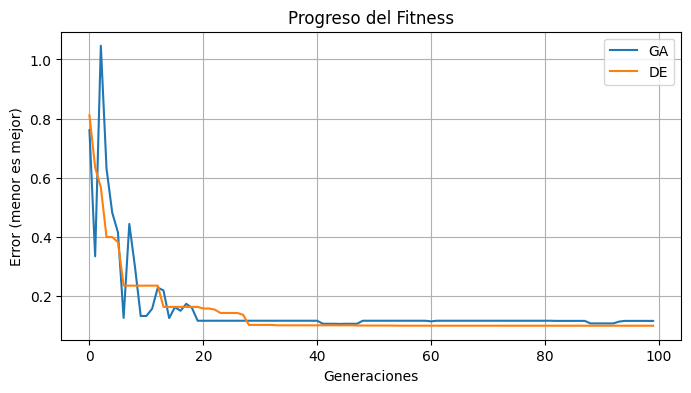

In [ ]:
import random
import math
import numpy as np
import matplotlib.pyplot as plt


# CONFIGURACIÓN DEL PROBLEMA


# Ecuación cuadrática: ax² + bx + c = 0
a, b, c = 1, -3, 2  # f(x) = x² - 3x + 2 = 0
# Raíces reales exactas: x1 = 1, x2 = 2


# FUNCIÓN OBJETIVO


def f(x):
    #Evalúa la ecuación cuadrática.
    return a * x**2 + b * x + c

def fitness(individual):

    #Función de aptitud (fitness) para el GA y DE.
    #Cada individuo tiene 2 genes: [x1, x2]
    #El fitness mide cuán cerca están ambos genes de ser raíces reales.

    x1, x2 = individual
    # Queremos minimizar la suma de los valores absolutos de f(x1) y f(x2)
    error = abs(f(x1)) + abs(f(x2))
    # Penalización si las raíces son muy parecidas (queremos dos distintas)
    penalty = 1.0 / (abs(x1 - x2) + 1e-6)
    return error + 0.1 * penalty


# PARÁMETROS DEL ALGORITMO GENÉTICO (GA)


POP_SIZE = 50
GENERATIONS = 100
MUTATION_RATE = 0.2
X_MIN, X_MAX = -10, 10

def genetic_algorithm():
    #Algoritmo genético para encontrar las dos raíces.
    # Población inicial: pares de valores [x1, x2]
    population = [[random.uniform(X_MIN, X_MAX), random.uniform(X_MIN, X_MAX)] for _ in range(POP_SIZE)]
    best_fitness = []

    for gen in range(GENERATIONS):
        # Evaluar fitness
        scored = [(ind, fitness(ind)) for ind in population]
        scored.sort(key=lambda x: x[1])
        best = scored[0][0]
        best_fitness.append(scored[0][1])

        # Selección (por torneo simple)
        parents = [scored[i][0] for i in range(POP_SIZE // 2)]

        # Cruza y mutación
        offspring = []
        while len(offspring) < POP_SIZE:
            p1, p2 = random.sample(parents, 2)
            # Cruza de un punto
            cross = [p1[0], p2[1]]
            # Mutación
            if random.random() < MUTATION_RATE:
                cross[0] += random.uniform(-1, 1)
            if random.random() < MUTATION_RATE:
                cross[1] += random.uniform(-1, 1)
            # Aseguramos límites
            cross = [max(X_MIN, min(X_MAX, x)) for x in cross]
            offspring.append(cross)

        population = offspring

    # Devuelve el mejor individuo y su progreso
    best = min(population, key=fitness)
    return best, best_fitness


# ALGORITMO DE EVOLUCIÓN DIFERENCIAL (DE)

def differential_evolution():
    #Algoritmo de evolución diferencial.
    F = 0.8   # factor de mutación
    CR = 0.9  # tasa de recombinación

    population = np.random.uniform(X_MIN, X_MAX, size=(POP_SIZE, 2))
    best_fitness = []

    for gen in range(GENERATIONS):
        new_population = []
        for i in range(POP_SIZE):
            # Selección de tres vectores distintos
            idxs = [idx for idx in range(POP_SIZE) if idx != i]
            a_, b_, c_ = population[np.random.choice(idxs, 3, replace=False)]

            # Mutación
            mutant = a_ + F * (b_ - c_)

            # Recombina
            cross_points = np.random.rand(2) < CR
            if not np.any(cross_points):
                cross_points[np.random.randint(0, 2)] = True
            trial = np.where(cross_points, mutant, population[i])

            # Asegurar límites
            trial = np.clip(trial, X_MIN, X_MAX)

            # Selección
            if fitness(trial) < fitness(population[i]):
                new_population.append(trial)
            else:
                new_population.append(population[i])

        population = np.array(new_population)
        best_fitness.append(min([fitness(ind) for ind in population]))

    best = min(population, key=fitness)
    return best, best_fitness


# EJECUCIÓN Y RESULTADOS

# Ejecutar ambos métodos
best_ga, hist_ga = genetic_algorithm()
best_de, hist_de = differential_evolution()

# Mostrar resultados
print("Ecuación cuadrática: {}x² + ({}x) + ({}) = 0".format(a, b, c))
print("Raíces exactas: x1 = 1, x2 = 2\n")

print("Resultados del Algoritmo Genético:")
print(f"  GA -> x1 = {best_ga[0]:.4f}, x2 = {best_ga[1]:.4f}, errores = {abs(f(best_ga[0])):.2e}, {abs(f(best_ga[1])):.2e}")

print("\nResultados de Evolución Diferencial:")
print(f"  DE -> x1 = {best_de[0]:.4f}, x2 = {best_de[1]:.4f}, errores = {abs(f(best_de[0])):.2e}, {abs(f(best_de[1])):.2e}")


# GRÁFICA DEL PROGRESO


plt.figure(figsize=(8, 4))
plt.plot(hist_ga, label="GA")
plt.plot(hist_de, label="DE")
plt.title("Progreso del Fitness")
plt.xlabel("Generaciones")
plt.ylabel("Error (menor es mejor)")
plt.legend()
plt.grid(True)
plt.show()

